# HW 13 - Introduction to SciPy
ULAB - Physics and Astronomy Division
Due **Sunday, February 16th, 2025 at 11:59 PM** on Gradescope.

------

## 0 Academic Integrity

Please type the following message in the cell below as a comment. Sign with your name.

------

**I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.**

------


In [ ]:
# Your comment here
#I certify that I did not use AI tools, such as ChatGPT, 
#to generate or write code for this assignment. 
# All work submitted is my own and reflects my understanding of the material.

# Melina Handan



## 1 Simulate a Pendulum
A simple pendulum follows the equation:

$$
\frac{\text{d}^2\theta}{\text{d}t^2} + \frac{g}{L}\sin(\theta) = 0
$$

The goal is to **numerically solve the equation** and compare it to the small-angle approximation.

***Small-Angle Approximation:** a mathematical simplification used in physics when dealing with osciallatory motion, particularly for pendulums and trigonometric funcitons in general.*

Import `numpy`, `matplotlib` and `solve_ivp` in the cell below.

In [1]:
# Your code here 
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Define the acceleration of gravity $g$ (two significant digits is fine) and the length of the pendulum $l$ in the cell below to **1 meter**.

In [2]:
# Your code here
g = 9.81 #meter/s^2
L = 1.0  #meters

Write a **function** called `pendulum` that contain the arguments `t` and `y`. Write out the differential equation. Follow the structure Brianna gave in lecture, it's very similar.

*Hint: The variable domega/dt should be equal to -(g / L) * np.sin(theta)*. I'll let you take care of the rest. 

In [3]:
# Your code here
def pendulum(t, y):
    theta, omega = y #y[0] = theta, y[1] = omega
    dtheta_dt = omega
    domega_dt = -(g/L)*np.sin(theta)
    return [dtheta_dt, domega_dt]


Give you equation some initial conditions. Run the cell below.

In [4]:
theta_0 = np.radians(10) # Convert 10 degrees to radians
omega_0 = 0.0 # Initial angular velocity



Solve the differential equation using `solve_ivp`. Set the simulation time to **10 seconds** and the time for evaluation to **10 steps**.

In [5]:
# Your code here
t_span = (0, 10) # 10-sec simulation
t_eval = np.linspace(0, 10, 500) # time steps for evaluation
sol = solve_ivp(pendulum, t_span, [theta_0, omega_0], t_eval=t_eval)
print(sol)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.004e-02 ...  9.980e+00  1.000e+01]
        y: [[ 1.745e-01  1.742e-01 ...  1.707e-01  1.726e-01]
            [ 0.000e+00 -3.412e-02 ...  1.120e-01  7.842e-02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 218
     njev: 0
      nlu: 0


Extract the **theta** values (`sol.y`) and the **time** values (`sol.t`).

In [6]:
# Your code here
theta_values = sol.y[0]
time_values = sol.t

print(f"Theta values: {theta_values}")
print(f"Time values: {time_values}")

Theta values: [ 0.17453293  0.17419097  0.17316644  0.17146329  0.16908857  0.1660522
  0.16236546  0.15804208  0.15309833  0.14755293  0.14142714  0.13474472
  0.12753192  0.11981748  0.11163268  0.10301127  0.09398569  0.08459012
  0.07486253  0.06484153  0.05456631  0.0440767   0.03341314  0.02261669
  0.01172902  0.00079243 -0.01015019 -0.0210553  -0.03187877 -0.04257585
 -0.05310115 -0.06341295 -0.0734805  -0.08326177 -0.09271571 -0.10180347
 -0.11048841 -0.1187361  -0.1265143  -0.133793   -0.14054437 -0.14674282
 -0.15236494 -0.15738954 -0.16179763 -0.16557244 -0.16870008 -0.17117338
 -0.17298104 -0.17411315 -0.17456291 -0.17432659 -0.17340361 -0.17179645
 -0.16951071 -0.1665551  -0.16294141 -0.15868454 -0.1538025  -0.14831638
 -0.14225041 -0.13563188 -0.12848933 -0.12084395 -0.11272487 -0.10416392
 -0.09519426 -0.08585033 -0.07616794 -0.06618416 -0.0559374  -0.04546738
 -0.03481513 -0.024023   -0.01313464 -0.00219502  0.00874956  0.01965375
  0.03048471  0.04119878  0.05175108  

Calculate the theoretical period (aka small-angle approximation).

*Hint: Use `2 * np.pi * np.sqrt(L / g)`.*

In [7]:
# Your code here 

def period(L):
    return 2*np.pi * np.sqrt(L/g)

Print out the theoretical period (small-angle approximation) to **two** significant digits.

In [8]:
# Your code here
print(period(L))

2.0060666807106475


Estimate the period from simulation by finding the first zero crossing. Run the cell below.

In [9]:
zero_crossings = np.where(np.diff(np.sign(theta_values)))[0]
if len(zero_crossings) >= 2:
    T_numerical = 2 * (time_values[zero_crossings[1]] - time_values[zero_crossings[0]])
else:
    T_numerical = None

Plot the results in the cell below. Add a **horizontal** line at `x=0`, give it an `x_label` of **Time (s)**, a `y_label` of **Theta (radians)** and a title.

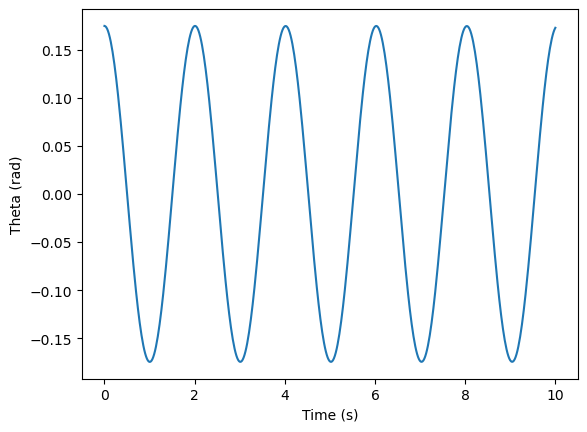

In [10]:
# Your code here
plt.plot(time_values, theta_values, label='numerical solution')
plt.xlabel("Time (s)")
plt.ylabel("Theta (rad)")
plt.show()


Print out the numerical period (what you calculated with scipy) to **four** significant digits.

In [ ]:
# Your code here

Compare the results between the small-angle approximation and numerical calculation. How well does the approximation match the numerical result?

In [ ]:
# Your comment here

## 2 Using Curve_Fit with Covid-19 Data
Import `pandas` in the cell below.

In [11]:
# Your code here
import pandas as pd

Run the cell below. If that doesn't work, then just **paste** the link into a web browser and it should automatically download. Then you can put the `.csv` file in the same directory as this notebook.

In [19]:
url = "https://covid.ourworldindata.org/data/owid-covid-data.csv"

With the `pandas` function `read_csv`, import the data in the cell below as a dataframe `df`.

In [17]:
# Your code here
df = pd.read_csv('owid-covid-data.csv')
print(df)

       iso_code continent     location        date  total_cases  new_cases  \
0           AFG      Asia  Afghanistan  2020-01-05          0.0        0.0   
1           AFG      Asia  Afghanistan  2020-01-06          0.0        0.0   
2           AFG      Asia  Afghanistan  2020-01-07          0.0        0.0   
3           AFG      Asia  Afghanistan  2020-01-08          0.0        0.0   
4           AFG      Asia  Afghanistan  2020-01-09          0.0        0.0   
...         ...       ...          ...         ...          ...        ...   
429430      ZWE    Africa     Zimbabwe  2024-07-31     266386.0        0.0   
429431      ZWE    Africa     Zimbabwe  2024-08-01     266386.0        0.0   
429432      ZWE    Africa     Zimbabwe  2024-08-02     266386.0        0.0   
429433      ZWE    Africa     Zimbabwe  2024-08-03     266386.0        0.0   
429434      ZWE    Africa     Zimbabwe  2024-08-04     266386.0        0.0   

        new_cases_smoothed  total_deaths  new_deaths  new_death

Select **United States** as the country and make a new data frame called `df_country` with only this information.

In [24]:
# Your code here

df_country = df[df['iso_code']== 'USA']
print(df_country)


       iso_code      continent       location        date  total_cases  \
403451      USA  North America  United States  2020-01-05          0.0   
403452      USA  North America  United States  2020-01-06          0.0   
403453      USA  North America  United States  2020-01-07          0.0   
403454      USA  North America  United States  2020-01-08          0.0   
403455      USA  North America  United States  2020-01-09          0.0   
...         ...            ...            ...         ...          ...   
405120      USA  North America  United States  2024-07-31  103436829.0   
405121      USA  North America  United States  2024-08-01  103436829.0   
405122      USA  North America  United States  2024-08-02  103436829.0   
405123      USA  North America  United States  2024-08-03  103436829.0   
405124      USA  North America  United States  2024-08-04  103436829.0   

        new_cases  new_cases_smoothed  total_deaths  new_deaths  \
403451        0.0                 NaN       

From your `df_country` dataframe, extract only the relevant columns: **"date"** and **"total_cases"**. 

*Hint: Use `.dropna()` to get rid of the other data.*

In [33]:
# Your code here
df_country2 = df_country[['date', 'total_cases']]
print(df_country2)

              date  total_cases
403451  2020-01-05          0.0
403452  2020-01-06          0.0
403453  2020-01-07          0.0
403454  2020-01-08          0.0
403455  2020-01-09          0.0
...            ...          ...
405120  2024-07-31  103436829.0
405121  2024-08-01  103436829.0
405122  2024-08-02  103436829.0
405123  2024-08-03  103436829.0
405124  2024-08-04  103436829.0

[1674 rows x 2 columns]


In your `df_country` dataframe, add a new column called **"days since start"** and covert the data to numerical days.

*Hint: You can just take the length of your dataframe (`range(len(df_country))`).*

In [54]:
# Your code here
print(df_country2.assign(['days_since_start']))

TypeError: DataFrame.assign() takes 1 positional argument but 2 were given

Print the first few rows of your `df_country` dataframe.

In [ ]:
# Your code here

In the cell below, import `curve_fit`. Make sure to have `numpy` imported in this notebook as well.

In [ ]:
# Your code here

### Some background:
At the beginning of an outbreak, the number of cases follows an exponential growth model:

$$
C(t) = C_0 e^{rt}
$$

where
* $C(t)$ = number of cases at time $t$.
* $C_0$ = initial number of cases.
* $r$ = growth rate.
* $t$ = time in days.

Write a **function** called `exponential_growth` that takes in arguments `t`, `C_0` and `r`. Return the function given above.

In [ ]:
# Your code here

Make a new variable called `days` and another new variable called `cases`. To the `days` variable give it the first 30 rows (your column **"days_since_start"**) and to the `cases` variable give it the first 30 rows (your column **"total_cases"**).

In [ ]:
# Your code here

With `curve_fit` fit the model. Give it the argument `p0 = [1, 0.1]`.

In [ ]:
# Your code here

Extract the best-fit parameters from `popt`. Call them `C0_fit` and `r_fit`.

In [ ]:
# Your code here

Print your variables `C0_fit` with **two** significant digits. Print your variables `r_fit` with **four** significant digits.

In [ ]:
# Your code here

Make sure to have `matplotlib` imported. Make a variable called `future_days` give it a numpy range from `0` to `60`. We want to predict up to 60 days.

In [ ]:
# Your code here

Make a variable called `predicted_cases` set it equal to your function `exponential_growth` with inputs being `future_days` and your `curve_fit` outputs. 

*Hint: You will want to use `*popt` as your `curve_fit` input.*

In [ ]:
# Your code here 

**Scater** the variable `cases` as a function of `days`. **Plot** the variable `future_days` as a function of `predicted_cases`. 

Don't forget a label for your x-axis, y-axis, title and legend.

In [ ]:
# Your code here

How well does your exponential model fit the actual COVID-19 data? 

In [ ]:
# Your comment here

Make another plot but this time to **90 days**.

In [ ]:
# Your code here

What does your model predict the number of cases to be at 87 days? Print in the cell below.

In [ ]:
# Your code here

## 3 Seaborn
Use Seaborn to visualize your data, NOT matplotlib. 
1) Go to this website and **pick a dataset that interest you**: https://github.com/mwaskom/seaborn-data
2) Go to this website for documentation: https://seaborn.pydata.org/index.html
3) Import seaborn data (*Hint: You can use the function `sns.load dataset()`. For example, `sns.load dataset('planets')`.*
4) Make a cool plot!
5) With `scipy` add a model to your data. (This can be a different plot.)

In [ ]:
# Your code here

On it's own branch, submit this notebook to Gradescope! 